# 📊 Amazon Sales Data Analysis

## Project Overview
This project analyzes Amazon sales data to uncover insights related to sales performance,
profitability, order processing efficiency, and customer demand across regions, countries,
item types, and sales channels.

## Objectives
- Analyze total revenue and profit trends
- Identify top-performing regions and countries
- Understand pricing and demand patterns
- Evaluate order processing efficiency
- Detect outliers and relationships in sales data


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')


In [ ]:
data = pd.read_csv(
    r"C:\Users\Dell\OneDrive\Desktop\Self Class\VIP\Python Project\Amazon Sales data.csv"
)
data= pd.DataFrame(data= data)
data

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,05-02-2014,341417157,05-08-2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,07-05-2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,02-01-2013,115456712,02-06-2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Sub-Saharan Africa,Mali,Clothes,Online,M,7/26/2011,512878119,09-03-2011,888,109.28,35.84,97040.64,31825.92,65214.72
96,Asia,Malaysia,Fruits,Offline,L,11-11-2011,810711038,12/28/2011,6267,9.33,6.92,58471.11,43367.64,15103.47
97,Sub-Saharan Africa,Sierra Leone,Vegetables,Offline,C,06-01-2016,728815257,6/29/2016,1485,154.06,90.93,228779.10,135031.05,93748.05
98,North America,Mexico,Personal Care,Offline,M,7/30/2015,559427106,08-08-2015,5767,81.73,56.67,471336.91,326815.89,144521.02


## Data Cleaning & Preparation
- Converted date columns to datetime format
- Created a new feature: Processing Time (days)
- Ensured consistent column naming


In [ ]:
# Clean column names
data.columns = data.columns.str.strip()

# Convert dates
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')
data['Ship Date'] = pd.to_datetime(data['Ship Date'], errors='coerce')

# Create Processing Time
data['Processing Time'] = (data['Ship Date'] - data['Order Date']).dt.days

In [ ]:
data.columns # 

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit',
       'Processing Time'],
      dtype='object')

In [ ]:
data.shape

(100, 15)

In [ ]:
data.size

1500

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Region           100 non-null    object        
 1   Country          100 non-null    object        
 2   Item Type        100 non-null    object        
 3   Sales Channel    100 non-null    object        
 4   Order Priority   100 non-null    object        
 5   Order Date       66 non-null     datetime64[ns]
 6   Order ID         100 non-null    int64         
 7   Ship Date        64 non-null     datetime64[ns]
 8   Units Sold       100 non-null    int64         
 9   Unit Price       100 non-null    float64       
 10  Unit Cost        100 non-null    float64       
 11  Total Revenue    100 non-null    float64       
 12  Total Cost       100 non-null    float64       
 13  Total Profit     100 non-null    float64       
 14  Processing Time  43 non-null     float64   

In [ ]:
data.describe()

,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Processing Time
count,66,1.000000e+02,64,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02,1.000000e+02,43.000000
mean,2013-10-11 01:49:05.454545408,5.550204e+08,2013-10-31 15:22:30,5128.710000,276.761300,191.048000,1.373488e+06,9.318057e+05,4.416820e+05,25.418605
min,2010-05-28 00:00:00,1.146066e+08,2010-02-25 00:00:00,124.000000,9.330000,6.920000,4.870260e+03,3.612240e+03,1.258020e+03,0.000000
25%,2012-02-24 12:00:00,3.389225e+08,2012-02-06 00:00:00,2836.250000,81.730000,35.840000,2.687212e+05,1.688680e+05,1.214436e+05,15.000000
50%,2013-08-03 12:00:00,5.577086e+08,2013-11-04 12:00:00,5382.500000,179.880000,107.275000,7.523144e+05,3.635664e+05,2.907680e+05,29.000000
75%,2015-07-26 00:00:00,7.907551e+08,2015-09-03 00:00:00,7369.000000,437.200000,263.330000,2.212045e+06,1.613870e+06,6.358288e+05,33.500000
max,2017-05-22 00:00:00,9.940222e+08,2017-06-17 00:00:00,9925.000000,668.270000,524.960000,5.997055e+06,4.509794e+06,1.719922e+06,50.000000
std,NaN,2.606153e+08,NaN,2794.484562,235.592241,188.208181,1.460029e+06,1.083938e+06,4.385379e+05,13.846493


In [ ]:
data.isna().sum()

Region              0
Country             0
Item Type           0
Sales Channel       0
Order Priority      0
Order Date         34
Order ID            0
Ship Date          36
Units Sold          0
Unit Price          0
Unit Cost           0
Total Revenue       0
Total Cost          0
Total Profit        0
Processing Time    57
dtype: int64

In [ ]:
data.dtypes

Region                     object
Country                    object
Item Type                  object
Sales Channel              object
Order Priority             object
Order Date         datetime64[ns]
Order ID                    int64
Ship Date          datetime64[ns]
Units Sold                  int64
Unit Price                float64
Unit Cost                 float64
Total Revenue             float64
Total Cost                float64
Total Profit              float64
Processing Time           float64
dtype: object

In [ ]:
data = data.astype({'Ship Date': 'datetime64[ns]', 'Order Date': 'datetime64[ns]'})

In [ ]:
data.dtypes

Region                     object
Country                    object
Item Type                  object
Sales Channel              object
Order Priority             object
Order Date         datetime64[ns]
Order ID                    int64
Ship Date          datetime64[ns]
Units Sold                  int64
Unit Price                float64
Unit Cost                 float64
Total Revenue             float64
Total Cost                float64
Total Profit              float64
Processing Time           float64
dtype: object

<Axes: >

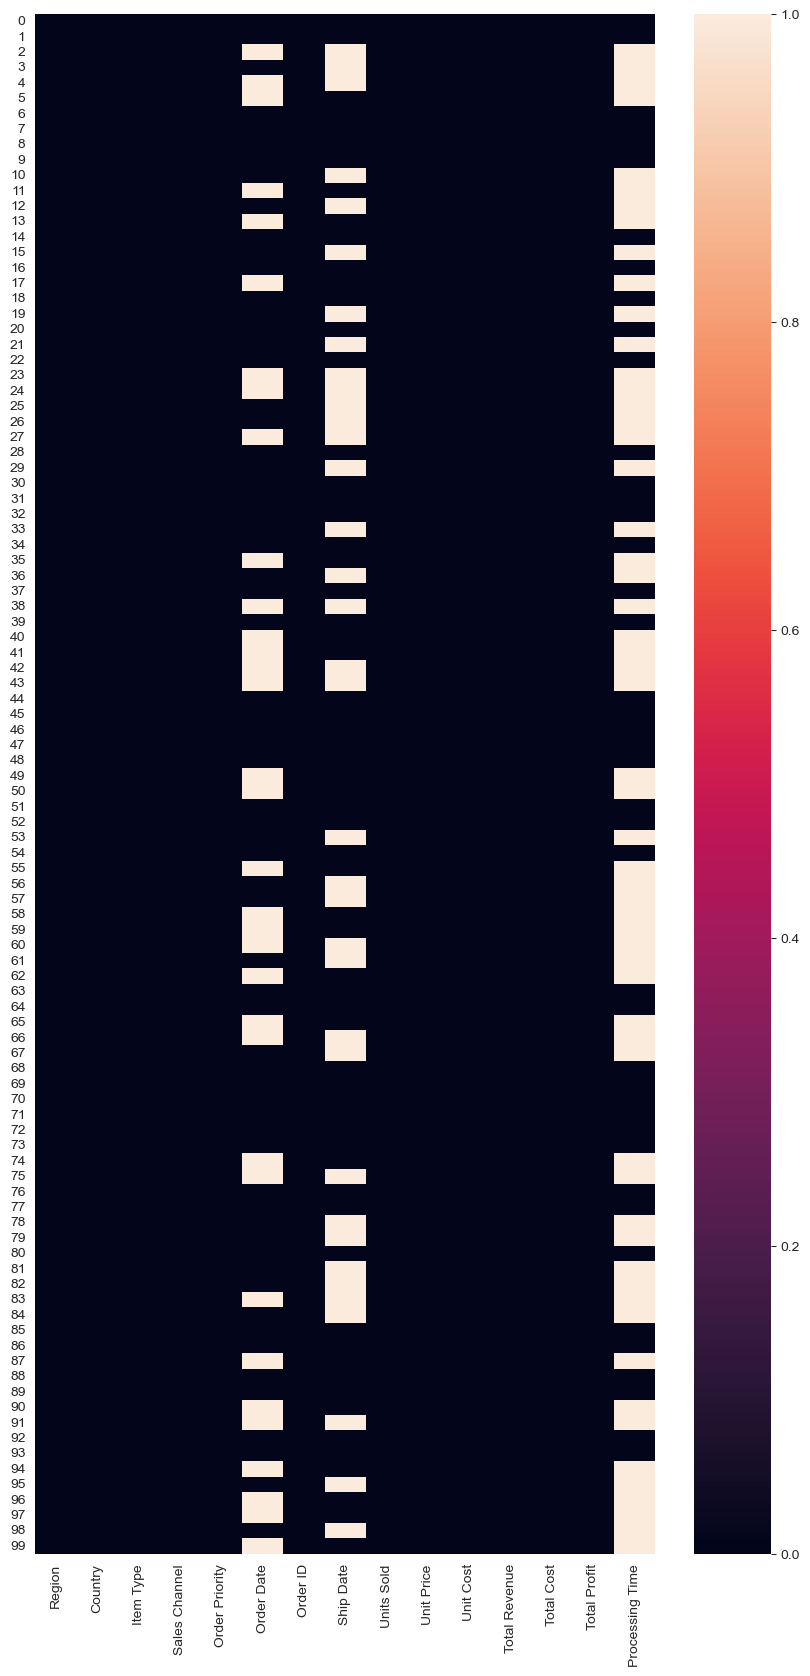

In [ ]:
plt.figure(figsize=(10,20))
sns.heatmap(data.isnull())     # NO ANY NULL VALUE PRESENT IN OUR DATASET.

In [ ]:
test = data.iloc[0, 12] = np.nan
# ADDING NULL VALUE JUST FOR DEMO
test

nan

<Axes: >

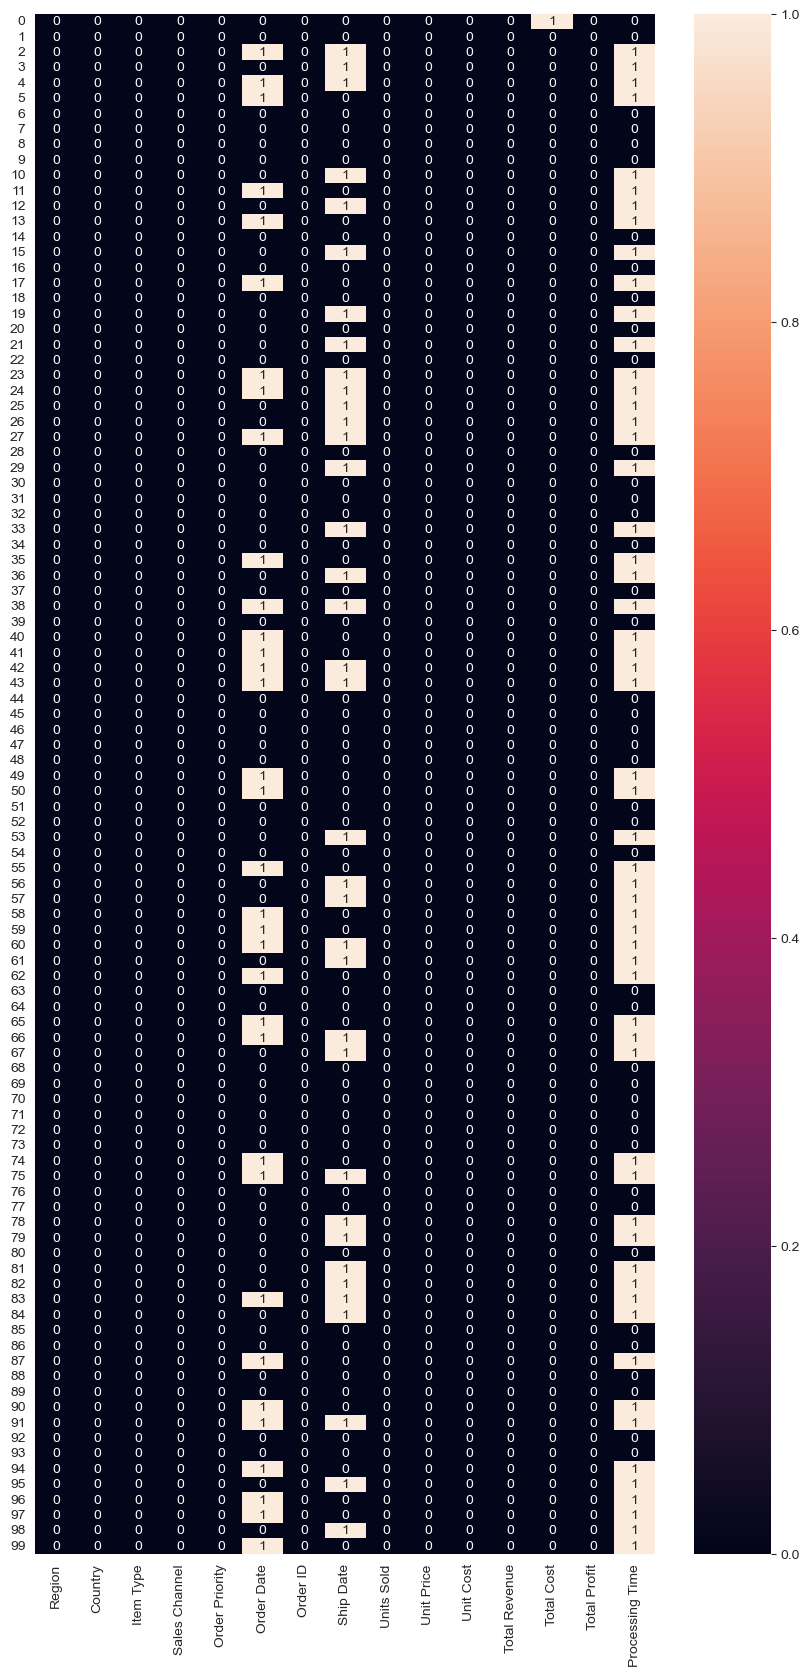

In [ ]:
plt.figure(figsize=(10,20))
sns.heatmap(data.isnull(), annot= True)#NULL VALUE FOUND IN 'TOTAL COST COLUMN

In [ ]:
data = data.fillna(data.mean()) #FILL MEAN WHERE NULL VALUE PRESENT

TypeError: Could not convert ['Australia and OceaniaCentral America and the CaribbeanEuropeSub-Saharan AfricaSub-Saharan AfricaAustralia and OceaniaSub-Saharan AfricaSub-Saharan AfricaSub-Saharan AfricaSub-Saharan AfricaAsiaSub-Saharan AfricaAsiaCentral America and the CaribbeanAsiaEuropeAsiaSub-Saharan AfricaAsiaAustralia and OceaniaEuropeEuropeCentral America and the CaribbeanAustralia and OceaniaEuropeEuropeAustralia and OceaniaSub-Saharan AfricaEuropeSub-Saharan AfricaEuropeSub-Saharan AfricaAustralia and OceaniaAsiaSub-Saharan AfricaCentral America and the CaribbeanMiddle East and North AfricaSub-Saharan AfricaAsiaEuropeSub-Saharan AfricaMiddle East and North AfricaSub-Saharan AfricaEuropeAsiaSub-Saharan AfricaEuropeEuropeEuropeSub-Saharan AfricaEuropeSub-Saharan AfricaMiddle East and North AfricaSub-Saharan AfricaSub-Saharan AfricaSub-Saharan AfricaAustralia and OceaniaEuropeEuropeSub-Saharan AfricaAustralia and OceaniaEuropeSub-Saharan AfricaMiddle East and North AfricaCentral A

In [ ]:
data['Total Cost']= data['Total Cost'].astype ('Float64')
data

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,2010-05-28,669165933,2010-06-27,9925,255.28,159.42,2533654.00,<NA>,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,2012-08-22,963881480,2012-09-15,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,2014-05-02,341417157,2014-05-08,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,2014-06-20,514321792,2014-07-05,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2013-02-01,115456712,2013-02-06,5062,651.21,524.96,3296425.02,2657347.52,639077.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Sub-Saharan Africa,Mali,Clothes,Online,M,2011-07-26,512878119,2011-09-03,888,109.28,35.84,97040.64,31825.92,65214.72
96,Asia,Malaysia,Fruits,Offline,L,2011-11-11,810711038,2011-12-28,6267,9.33,6.92,58471.11,43367.64,15103.47
97,Sub-Saharan Africa,Sierra Leone,Vegetables,Offline,C,2016-06-01,728815257,2016-06-29,1485,154.06,90.93,228779.10,135031.05,93748.05
98,North America,Mexico,Personal Care,Offline,M,2015-07-30,559427106,2015-08-08,5767,81.73,56.67,471336.91,326815.89,144521.02


<Axes: >

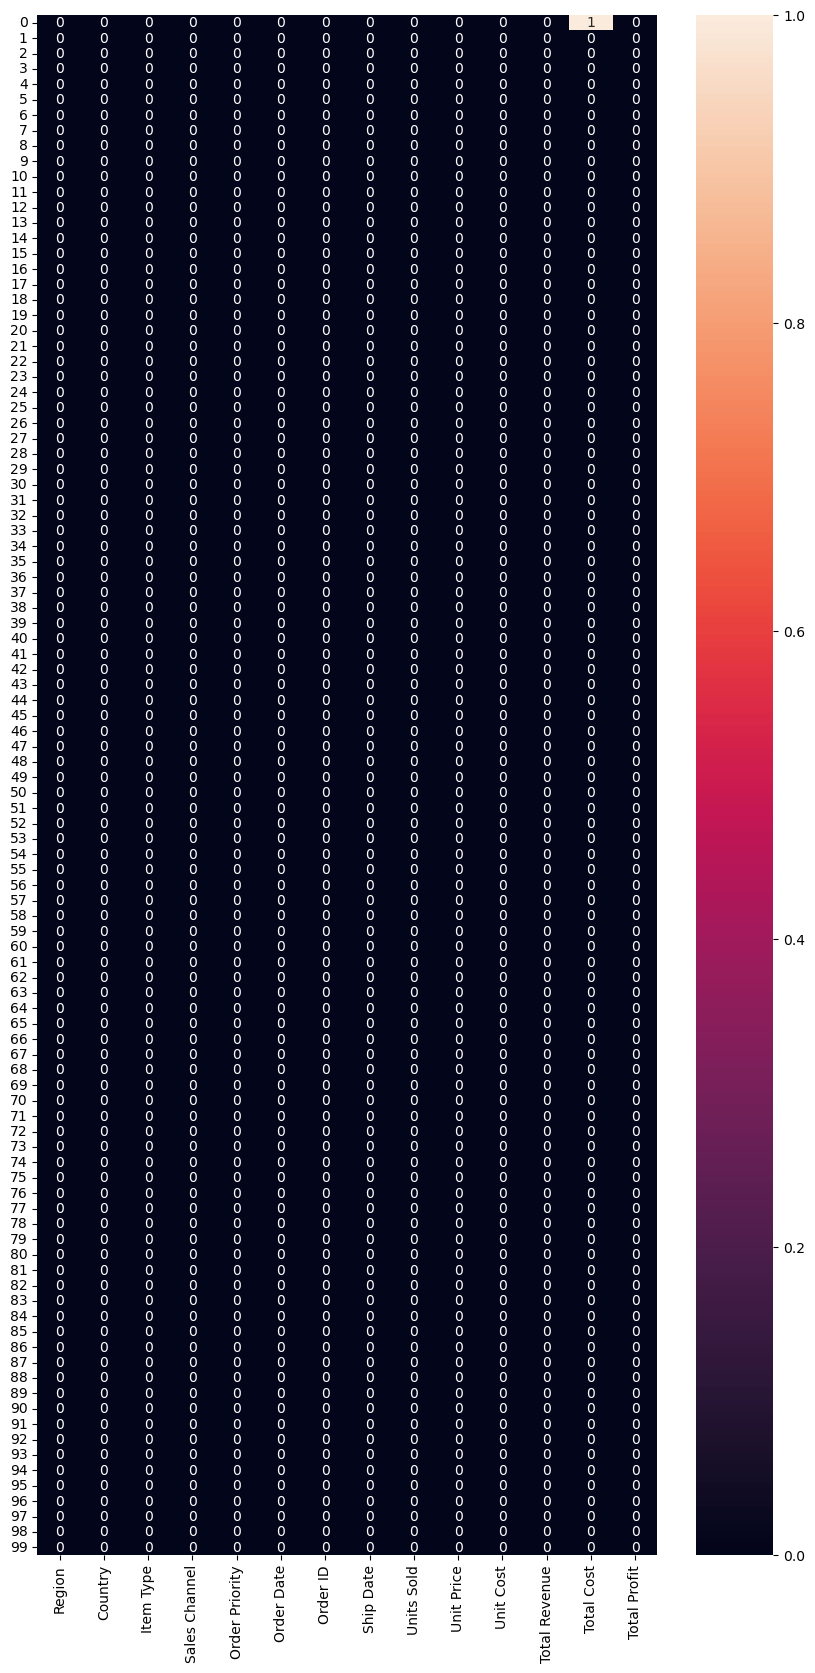

In [ ]:
plt.figure(figsize=(10,20))
sns.heatmap(data.isnull(), annot= True)
#NO NULL VALUES

In [ ]:
data.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Processing Time
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,2010-05-28,669165933,2010-06-27,9925,255.28,159.42,2533654.00,NaN,951410.50,30.0
1,Central America and the Caribbean,Grenada,Cereal,Online,C,2012-08-22,963881480,2012-09-15,2804,205.70,117.11,576782.80,328376.44,248406.36,24.0
2,Europe,Russia,Office Supplies,Offline,L,NaT,341417157,NaT,1779,651.21,524.96,1158502.59,933903.84,224598.75,NaN
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,2014-06-20,514321792,NaT,8102,9.33,6.92,75591.66,56065.84,19525.82,NaN
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,NaT,115456712,NaT,5062,651.21,524.96,3296425.02,2657347.52,639077.50,NaN


## 📊 Amazon Sales Data Analysis – Business Questions

### 1. Which regions have the highest total sales revenue?

### 2. What is the average unit price and unit cost for each item type?

### 3. Which country has the highest total profit?

### 4. How does the sales channel affect the order priority distribution?

### 5. What is the average order processing time for each sales channel?

### 6. Which item types have the highest and lowest total sales?

### 7. How does the order priority vary across different regions?

### 8. What is the correlation between unit price and total profit?

### 9. Are there any seasonal trends or patterns in the sales data?

### 10. How does the number of units sold vary across different countries?


In [ ]:
##1. Which regions have the highest total sales revenue?
Highest_Total_Revenue=data.groupby (data['Region']) ['Total Revenue'].sum()
Highest_Total_Revenue.idxmax()

'Sub-Saharan Africa'

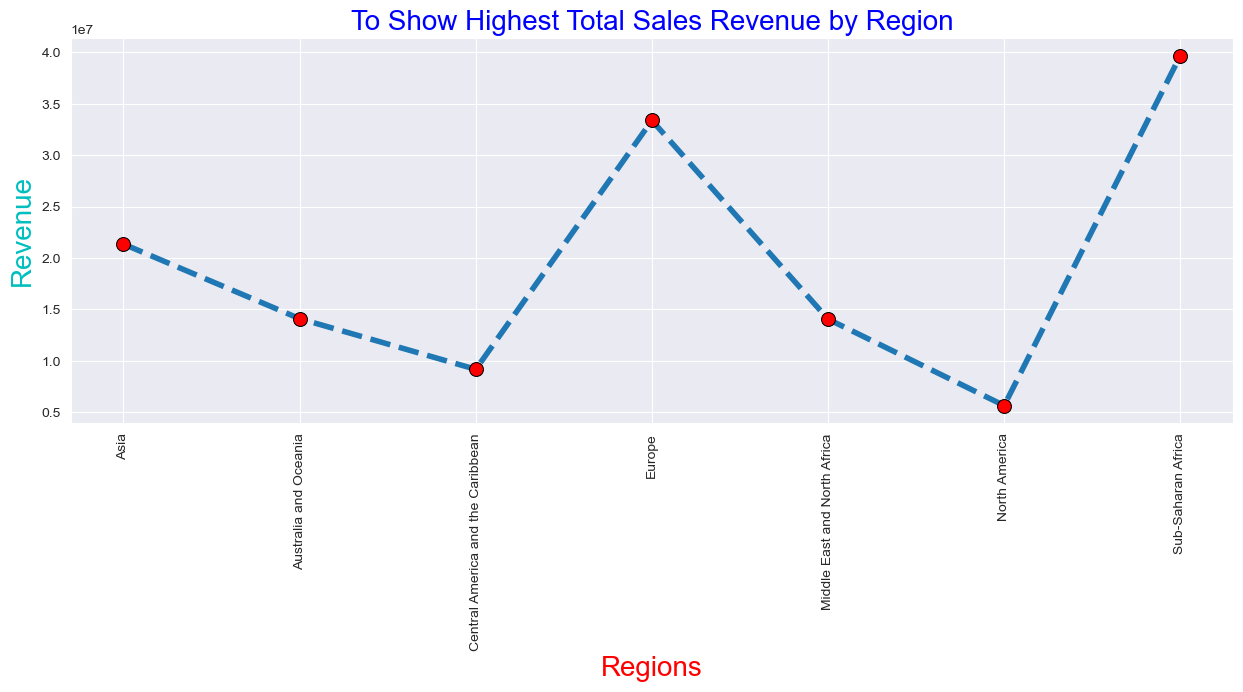

In [ ]:
group_data = data.groupby('Region')['Total Revenue'].sum()

sns.set_style('darkgrid')
plt.figure(figsize=(15,5))

sns.lineplot(
    x=group_data.index,
    y=group_data.values,
    linestyle='--',
    linewidth=4,
    marker='o',
    markersize=10,
    markerfacecolor='red',
    markeredgecolor='black'
)

plt.xticks(rotation=90)
plt.title('To Show Highest Total Sales Revenue by Region', fontsize=20, color='blue')
plt.xlabel('Regions', fontsize=20, color='red')
plt.ylabel('Revenue', fontsize=20, color='c')
plt.show()

#1e7 is scientific form. it means 1*10**7= 10,000,000


In [ ]:
#2. What is the average unit price and unit cost for each item type?
Avg_Unit_Price= data.groupby (data['Item Type']) ['Unit Price'].mean()
Avg_Unit_Cost =data.groupby (data['Item Type']) ['Unit Cost'].mean()
Avg_Price_Cost= pd.DataFrame({'Average Unit Price': Avg_Unit_Price,
'Average Unit Cost': Avg_Unit_Cost})
Avg_Price_Cost

,Average Unit Price,Average Unit Cost
Item Type,,
Baby Food,255.28,159.42
Beverages,47.45,31.79
Cereal,205.70,117.11
Clothes,109.28,35.84
Cosmetics,437.20,263.33
Fruits,9.33,6.92
Household,668.27,502.54
Meat,421.89,364.69
Office Supplies,651.21,524.96


In [ ]:
#3. Which country has the highest total profit?
Total_Profit_By_Comapany= data.groupby (data['Country']) ['Total Profit'].sum()
Highest_Total_Profit_County= Total_Profit_By_Comapany.idxmax()
print("Country with the highest total profit:", Highest_Total_Profit_County)

Country with the highest total profit: Djibouti


C:\Users\Dell\AppData\Local\Temp\ipykernel_6000\476503607.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


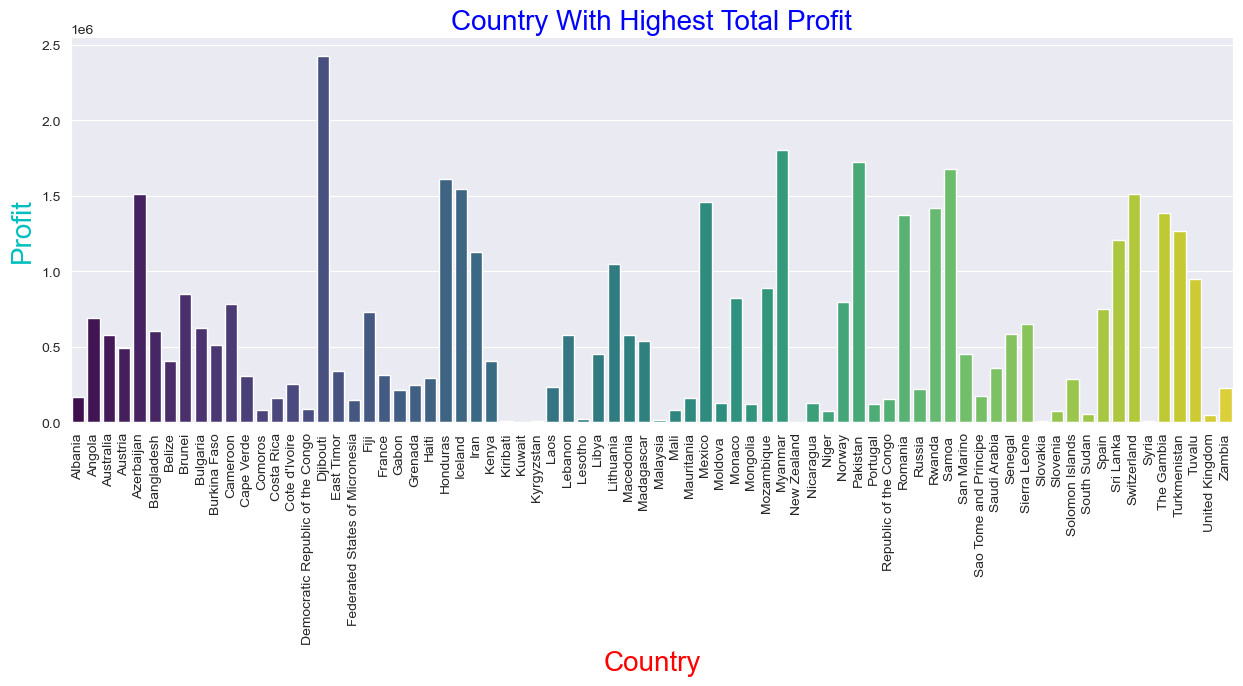

In [ ]:
group_data = data.groupby('Country')['Total Profit'].sum()

sns.set_style('darkgrid')
plt.figure(figsize=(15,5))

sns.barplot(
    x=group_data.index,
    y=group_data.values,
    palette='viridis'   # 🎨 Colorful palette
)

plt.xticks(rotation=90)
plt.title('Country With Highest Total Profit', fontsize=20, color='blue')
plt.xlabel('Country', fontsize=20, color='red')
plt.ylabel('Profit', fontsize=20, color='c')
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_23228\1487658307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


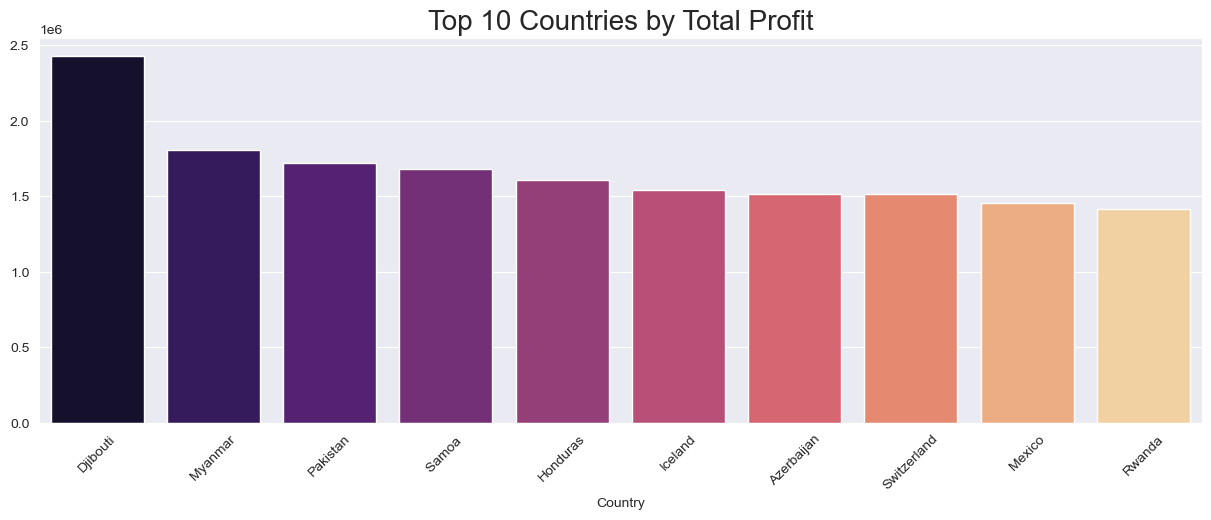

In [ ]:
#top 10 Countries
top10 = group_data.sort_values(ascending=False).head(10)

plt.figure(figsize=(15,5))
sns.barplot(
    x=top10.index,
    y=top10.values,
    palette='magma'
)

plt.xticks(rotation=45)
plt.title('Top 10 Countries by Total Profit', fontsize=20)
plt.show()


In [ ]:
##4- How does the sales channel affect the order priority distribution?
Sales_Channel_Order_Priority_Distribution= data.groupby (data['Sales Channel']) ['Order Priority'].value_counts()
Sales_Channel_Order_Priority_Distribution

Sales Channel  Order Priority
Offline        H                 17
               C                 13
               L                 12
               M                  8
Online         L                 15
               H                 13
               M                 13
               C                  9
Name: count, dtype: int64

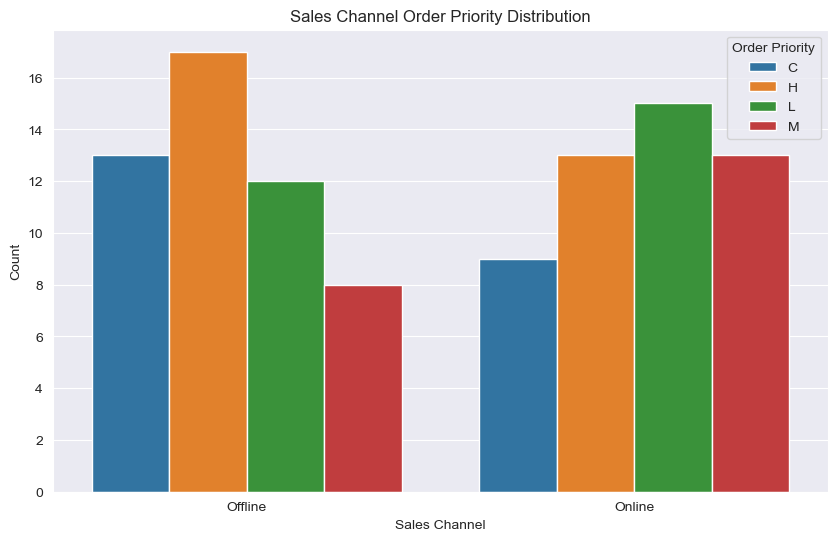

In [ ]:
# Group the data and count order priority
Sales_Channel_Order_Priority_Distribution = (
    data.groupby(['Sales Channel', 'Order Priority'])
    .size()
    .reset_index(name='Count')
)

# Set the style
sns.set_style('darkgrid')

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Sales Channel',
    y='Count',
    hue='Order Priority',
    data=Sales_Channel_Order_Priority_Distribution
)

# Add labels and title
plt.xlabel('Sales Channel')
plt.ylabel('Count')
plt.title('Sales Channel Order Priority Distribution')

# Display the plot
plt.show()


In [ ]:
##5- What is the average order processing time (duration between order and ship dates) for each sales channel?
data['Processing Time']= data['Ship Date']-data['Order Date']
Avg_Processing_Time= data.groupby (data['Sales Channel']) ['Processing Time'].mean()
Avg_Processing_Time

Sales Channel
Offline   23 days 04:48:00
Online    23 days 12:28:48
Name: Processing Time, dtype: timedelta64[ns]

C:\Users\Dell\AppData\Local\Temp\ipykernel_23228\2559907777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


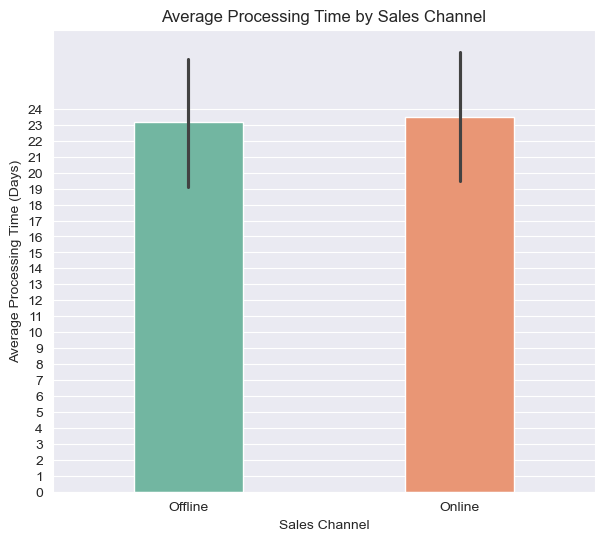

In [ ]:
plt.figure(figsize=(7, 6))

sns.barplot(
    data=data,
    x='Sales Channel',
    y=data['Processing Time'].dt.days,
    palette='Set2',     # 🎨 different colors
    width=0.4
)

plt.title('Average Processing Time by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Average Processing Time (Days)')
plt.yticks(np.arange(0, 25, 1))
plt.show()


In [ ]:
## 6- Which item types have the highest and lowest total sales?
group_item_type = data.groupby('Item Type')['Total Revenue'].sum()

highest_sales_revenue_item_type = group_item_type.idxmax()
lowest_sales_revenue_item_type = group_item_type.idxmin()

print(
    "Highest Sales Revenue By Item Type:", highest_sales_revenue_item_type,
    "\nLowest Sales Revenue By Item Type:", lowest_sales_revenue_item_type
)


Highest Sales Revenue By Item Type: Cosmetics 
Lowest Sales Revenue By Item Type: Fruits


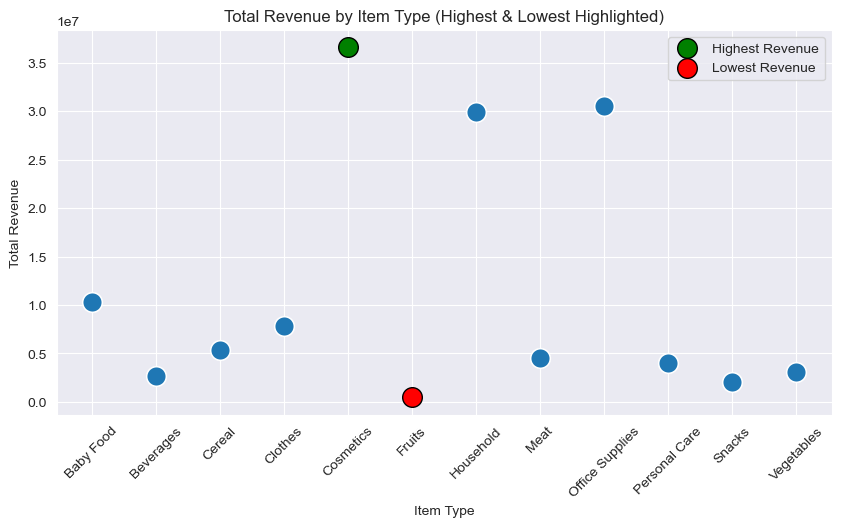

In [ ]:
plt.figure(figsize=(10,5))

# Base scatter plot
sns.scatterplot(
    x=group_item_type.index,
    y=group_item_type.values,
    s=200
)

# Highlight maximum value
max_index = group_item_type.idxmax()
plt.scatter(
    x=max_index,
    y=group_item_type.loc[max_index],
    s=200,
    color='green',
    edgecolor='black',
    label='Highest Revenue'
)

# Highlight minimum value
min_index = group_item_type.idxmin()
plt.scatter(
    x=min_index,
    y=group_item_type.loc[min_index],
    s=200,
    color='red',
    edgecolor='black',
    label='Lowest Revenue'
)

plt.xticks(rotation=45)
plt.title('Total Revenue by Item Type (Highest & Lowest Highlighted)')
plt.xlabel('Item Type')
plt.ylabel('Total Revenue')
plt.legend()
plt.show()


In [ ]:
##7- How does the order priority vary across different regions?
Diff_regions_by_order_priority= data.groupby (data['Region']) ['Order Priority'].value_counts()
Diff_regions_by_order_priority

Region                             Order Priority
Asia                               L                  4
                                   H                  3
                                   C                  2
                                   M                  2
Australia and Oceania              H                  5
                                   C                  4
                                   L                  1
                                   M                  1
Central America and the Caribbean  C                  2
                                   H                  2
                                   L                  2
                                   M                  1
Europe                             H                  7
                                   L                  6
                                   C                  5
                                   M                  4
Middle East and North Africa       L                  

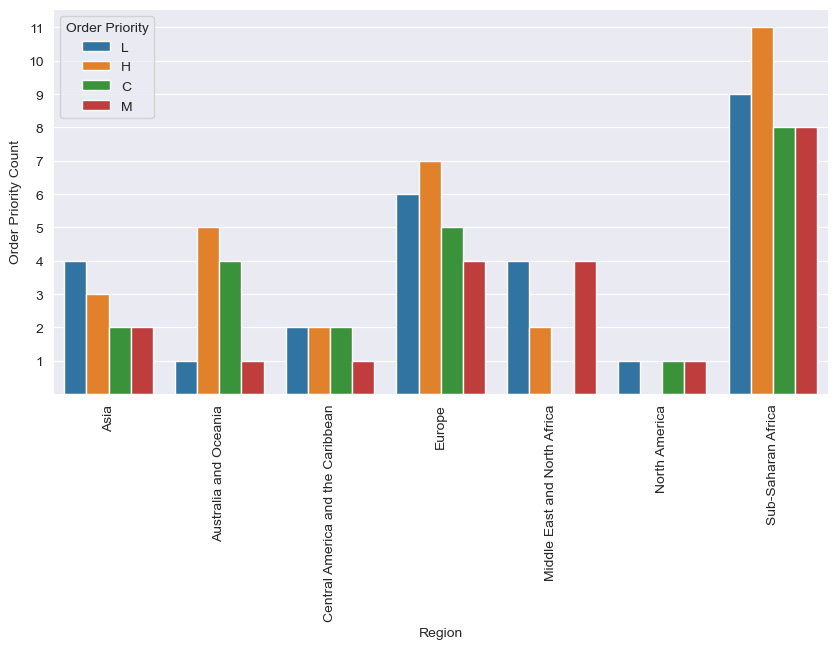

In [ ]:
Diff_regions_by_order_priority= data.groupby (data['Region']) ['Order Priority'].value_counts().reset_index(name='Order Priority Count')
plt.figure(figsize= (10,5))
sns.barplot(data= Diff_regions_by_order_priority, x= 'Region', y= 'Order Priority Count', hue= 'Order Priority')
plt.xticks(rotation= 90)
plt.yticks(np.arange(1,12,1))
plt.show()

In [ ]:
##- 8- What is the correlation between unit price and total profit?
Correlation_Unit_Price_Total_Profit= data['Unit Price'].corr(data['Total Profit'])
print("Correlation between Unit Price and Total Profit:", Correlation_Unit_Price_Total_Profit)

Correlation between Unit Price and Total Profit: 0.5573652488121267


<function matplotlib.pyplot.show(close=None, block=None)>

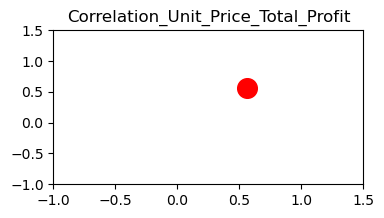

In [ ]:
plt.figure(figsize=(4,2))
plt.scatter(x= Correlation_Unit_Price_Total_Profit, y= Correlation_Unit_Price_Total_Profit, s =200, color= 'RED')
plt.xticks(np.arange(-1,2,0.5))
plt.yticks (np.arange(-1,2,0.5))
plt.title('Correlation_Unit_Price_Total_Profit')
plt.show

In [ ]:
## 9- Are there any seasonal trends or patterns in the sales data?
# Clean column names
data.columns = data.columns.str.strip()

# Ensure datetime
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')

# Month mapping
month_names = {
    1: 'JAN', 2: 'FEB', 3: 'MAR', 4: 'APR',
    5: 'MAY', 6: 'JUN', 7: 'JUL', 8: 'AUG',
    9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DEC'
}

# Monthly sales
month_sales = (
    data.groupby(data['Order Date'].dt.month)['Total Revenue']
    .sum()
)

month_sales.index = month_sales.index.map(month_names)

month_sales


Order Date
JAN     8846293.82
FEB     5884465.12
MAR     2028407.92
APR     8406818.15
MAY    11064739.47
JUN     4045279.41
JUL    10191773.17
AUG      672685.87
SEP     5294357.85
OCT    13303887.95
NOV    12269225.29
DEC     6632115.04
Name: Total Revenue, dtype: float64

C:\Users\Dell\AppData\Local\Temp\ipykernel_13228\3398809609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


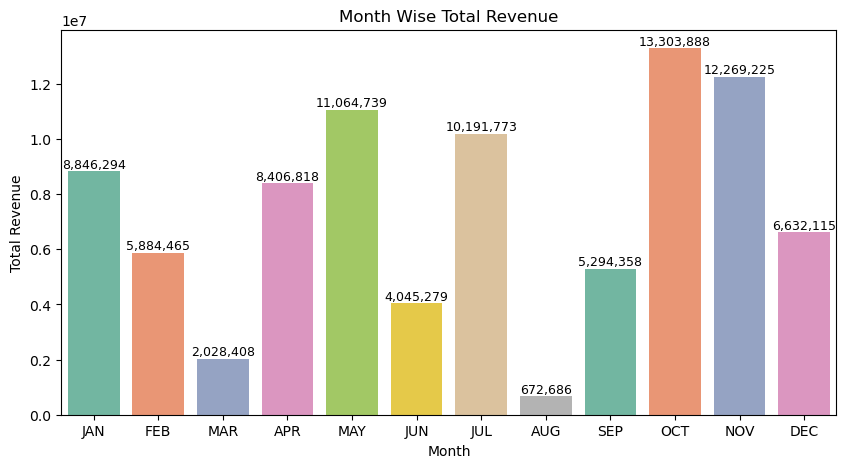

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=month_sales.index,
    y=month_sales.values,
    palette='Set2'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Month Wise Total Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()



In [ ]:
##10- How does the number of units sold vary across different countries?
Diff_countries_by_unit_sold = (
    data.groupby('Country')['Units Sold']
    .sum()
    .reset_index(name='Units Sold')
)

pd.set_option('display.max_rows', None)

Diff_countries_by_unit_sold


,Country,Units Sold
0,Albania,2269
1,Angola,4187
2,Australia,12995
3,Austria,2847
4,Azerbaijan,9255
5,Bangladesh,8263
6,Belize,5498
7,Brunei,6708
8,Bulgaria,5660
9,Burkina Faso,8082


C:\Users\Dell\AppData\Local\Temp\ipykernel_13228\1488173122.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


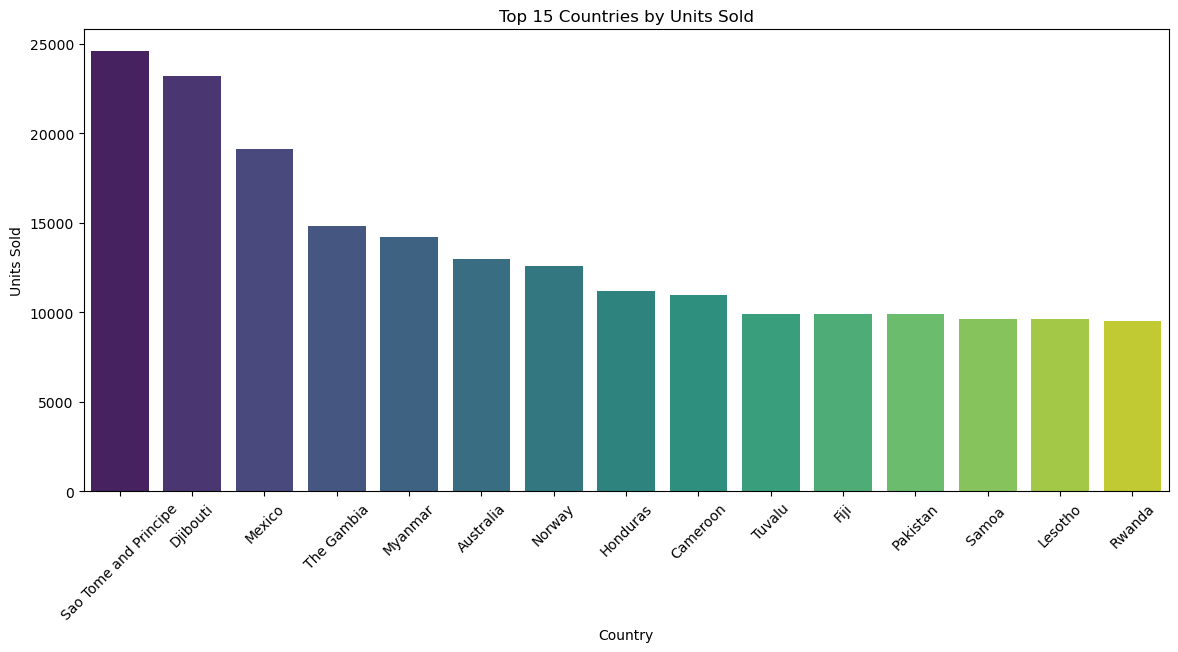

In [ ]:
top15 = Diff_countries_by_unit_sold.sort_values(
    by='Units Sold',
    ascending=False
).head(15)

plt.figure(figsize=(14,6))
sns.barplot(
    data=top15,
    x='Country',
    y='Units Sold',
    palette='viridis'
)

plt.xticks(rotation=45)
plt.title('Top 15 Countries by Units Sold')
plt.show()


### Other Queries
#### 11. How does the total sales revenue vary across different countries?
#### 12. What is the distribution of unit prices for each item type?
#### 13. Which sales channel has the highest average unit price?
#### 14. Are there any outliers in the total cost distribution?
#### 15. How does the total profit vary across different item types?
#### 16. What is the average order processing time for each country?
#### 17. Which region has the highest average total revenue per order?
#### 18. Is there a relationship between the number of units sold and the total profit?
#### 19. How does the order priority vary based on the item type?
#### 20. Are there any trends or patterns in the order dates?

In [ ]:
# 11 - How does the total sales revenue vary across different countries?
sales_revenue_by_countries = (
    data.groupby('Country')['Total Revenue']
    .sum()
    .reset_index(name='Total Revenue')
)

sales_revenue_by_countries


,Country,Total Revenue
0,Albania,247956.32
1,Angola,2798046.49
2,Australia,2489933.49
3,Austria,1244708.40
4,Azerbaijan,4478800.21
5,Bangladesh,902980.64
6,Belize,600821.44
7,Brunei,4368316.68
8,Bulgaria,2779199.71
9,Burkina Faso,1245112.92


C:\Users\Dell\AppData\Local\Temp\ipykernel_13228\3989299998.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


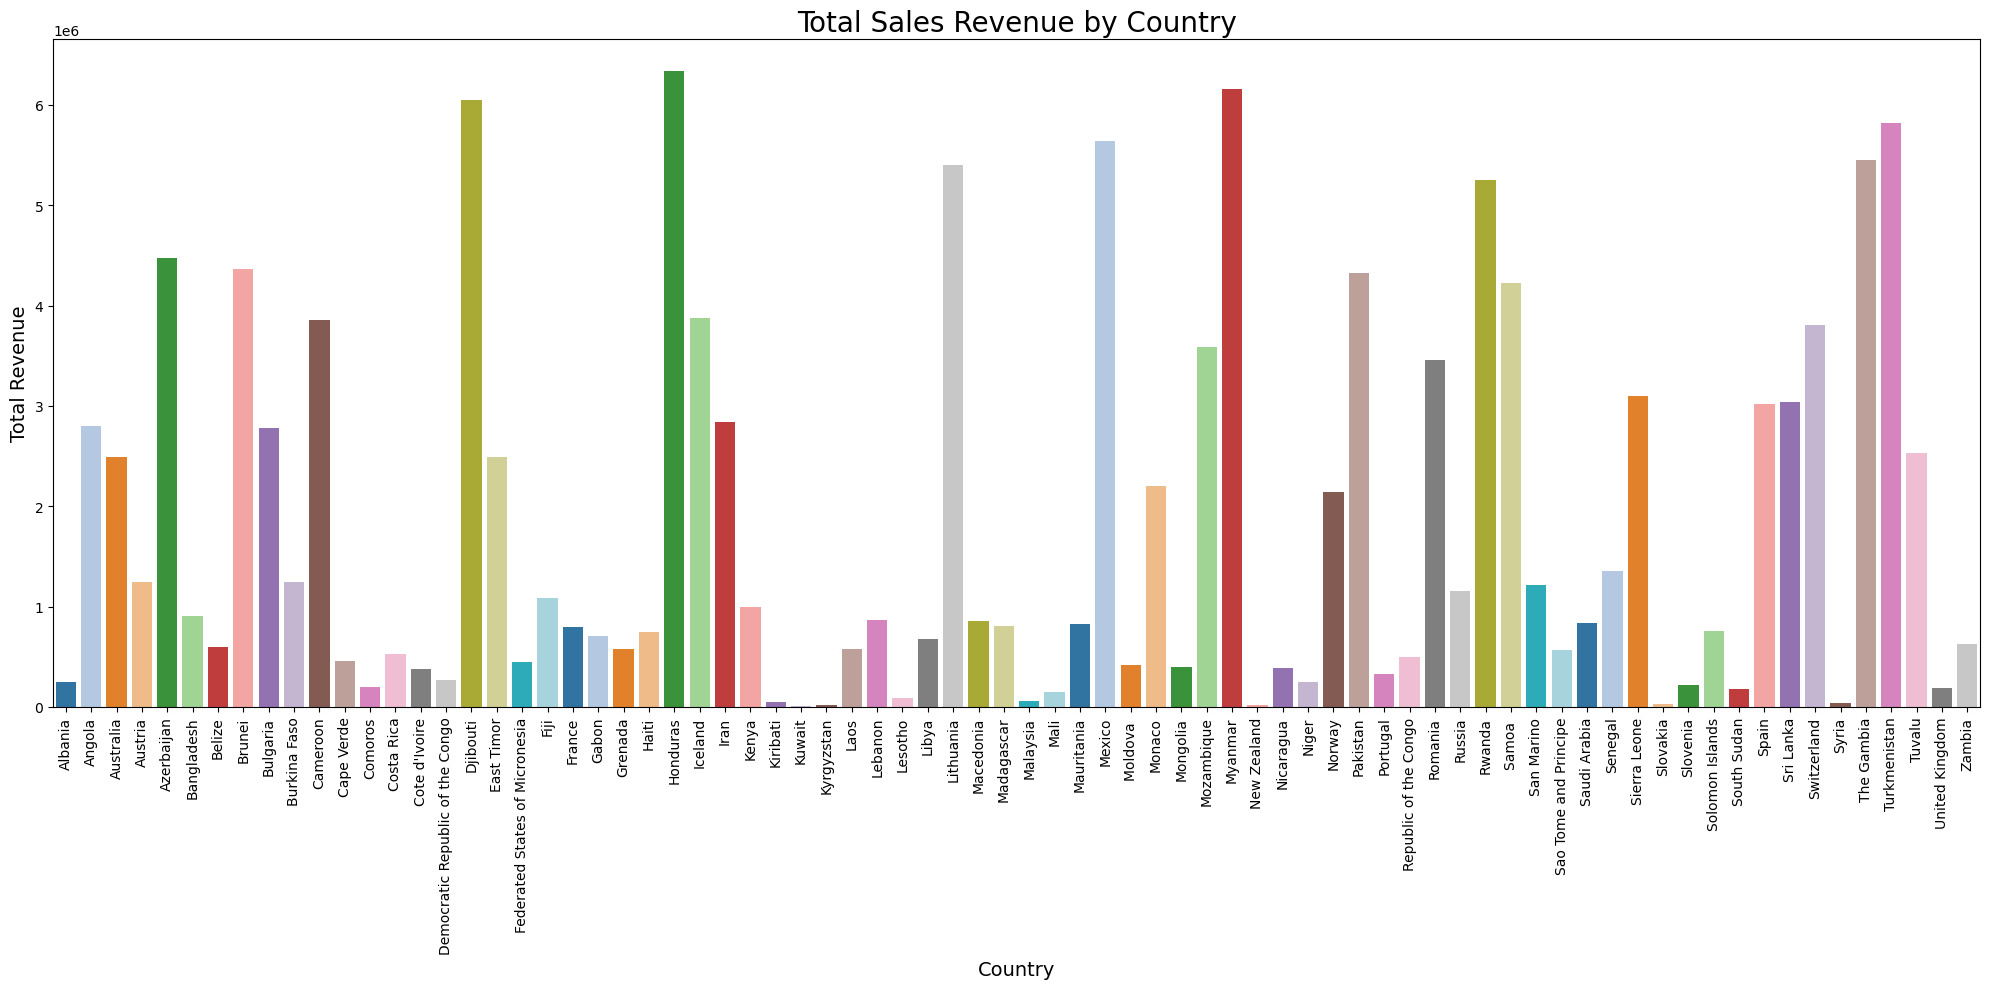

In [ ]:
plt.figure(figsize=(20,10))

sns.barplot(
    data=sales_revenue_by_countries,
    x='Country',
    y='Total Revenue',
    palette='tab20'
)

plt.xticks(rotation=90)
plt.title('Total Sales Revenue by Country', fontsize=20)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Total Revenue', fontsize=14)

plt.tight_layout()
plt.show()


In [21]:
## 12- What is the distribution of unit prices for each item type?
unit_price_item_type_distribution = (
    data.groupby('Item Type')['Unit Price']
    .mean()
    .reset_index(name='Average Unit Price')
)

unit_price_item_type_distribution


,Item Type,Average Unit Price
0,Baby Food,255.28
1,Beverages,47.45
2,Cereal,205.70
3,Clothes,109.28
4,Cosmetics,437.20
5,Fruits,9.33
6,Household,668.27
7,Meat,421.89
8,Office Supplies,651.21
9,Personal Care,81.73


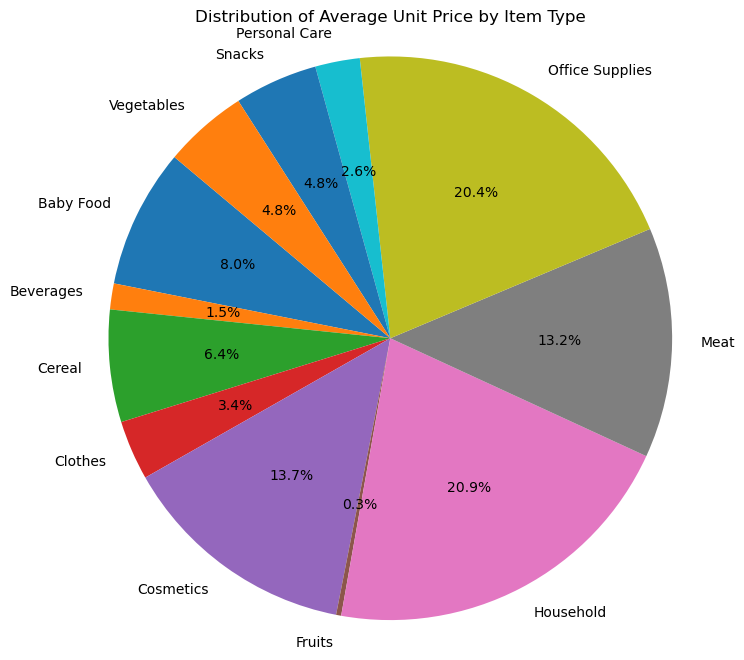

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    unit_price_item_type_distribution['Average Unit Price'],
    labels=unit_price_item_type_distribution['Item Type'],
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Distribution of Average Unit Price by Item Type')
plt.axis('equal')
plt.show()


In [ ]:
# 13 - Which sales channel has the highest average unit price?

Highest_avg_unit_price_for_sales_channel = (
    data.groupby('Sales Channel')['Unit Price']
    .mean()
    .reset_index(name='Average Unit Price')
)

Highest_avg_unit_price_for_sales_channel


,Sales Channel,Average Unit Price
0,Offline,310.7206
1,Online,242.8020


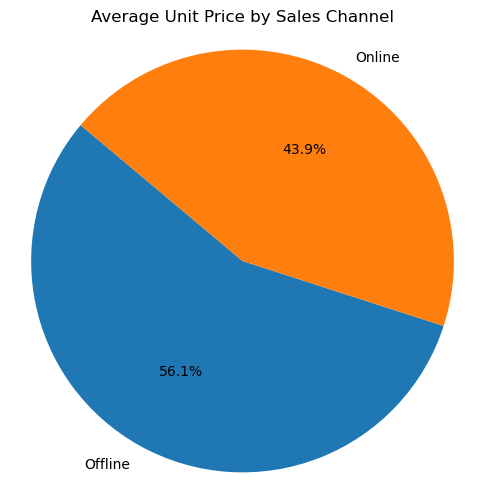

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    Highest_avg_unit_price_for_sales_channel['Average Unit Price'],
    labels=Highest_avg_unit_price_for_sales_channel['Sales Channel'],
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Average Unit Price by Sales Channel')
plt.axis('equal')
plt.show()

In [22]:
##14- Are there any outliers in the total cost distribution?
# Calculate Q1 and Q3
q1 = data['Total Cost'].quantile(0.25)
q3 = data['Total Cost'].quantile(0.75)

# Calculate IQR
iqr = q3 - q1

# Define fences
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

# Identify outliers
outliers = data[
    (data['Total Cost'] < lower_fence) |
    (data['Total Cost'] > upper_fence)
].reset_index(drop=True)

outliers


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Processing Time
0,Central America and the Caribbean,Honduras,Household,Offline,H,NaT,522840487,2017-02-13,8974,668.27,502.54,5997054.98,4509793.96,1487261.02,NaN
1,Asia,Myanmar,Household,Offline,H,2015-01-16,177713572,NaT,8250,668.27,502.54,5513227.50,4145955.00,1367272.50,NaN
2,Europe,Lithuania,Office Supplies,Offline,H,2010-10-24,166460740,2010-11-17,8287,651.21,524.96,5396577.27,4350343.52,1046233.75,24.0


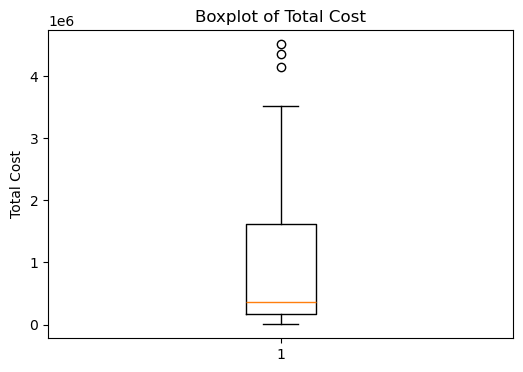

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(data['Total Cost'])
plt.title('Boxplot of Total Cost')
plt.ylabel('Total Cost')
plt.show()


In [ ]:
## 15- How does the total profit vary across different item types? 
total_profit_and_diff_item_types = (
    data.groupby('Item Type')['Total Profit']
    .sum()
    .reset_index(name='Total Profit')
)

total_profit_and_diff_item_types


,Item Type,Total Profit
0,Baby Food,3886643.70
1,Beverages,888047.28
2,Cereal,2292443.43
3,Clothes,5233334.40
4,Cosmetics,14556048.66
5,Fruits,120495.18
6,Household,7412605.71
7,Meat,610610.00
8,Office Supplies,5929583.75
9,Personal Care,1220622.48


In [ ]:
# 16 - Average order processing time for each country
Avg_Processing_Time_by_country = (
    data.groupby('Country')['Processing Time']
    .mean()
    .reset_index(name='Average Processing Time (Days)')
)

Avg_Processing_Time_by_country


,Country,Average Processing Time (Days)
0,Albania,NaN
1,Angola,4.0
2,Australia,29.0
3,Austria,NaN
4,Azerbaijan,41.0
5,Bangladesh,NaN
6,Belize,NaN
7,Brunei,NaN
8,Bulgaria,12.0
9,Burkina Faso,10.0


In [ ]:
##-17- Which region has the highest average total revenue per order?
# Create average revenue per order
data['Avg Revenue Per Order'] = data['Total Revenue'] / data['Units Sold']

# Average by region
avg_revenue_per_region = (
    data.groupby('Region')['Avg Revenue Per Order']
    .mean()
    .sort_values(ascending=False)
)

avg_revenue_per_region.head(1)


Region
Asia    335.809091
Name: Avg Revenue Per Order, dtype: float64

In [24]:
## 18-Is there a relationship between the number of units sold and the total profit?
correlation = data['Units Sold'].corr(data['Total Profit'])
correlation

np.float64(0.5645504620845976)

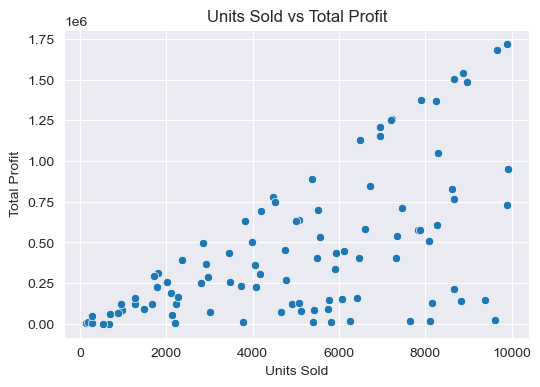

In [23]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=data,
    x='Units Sold',
    y='Total Profit'
)
plt.title('Units Sold vs Total Profit')
plt.show()

In [ ]:
##19- Is there a relationship between the number of units sold and the total profit?
correlation_unit_sold_total_profit = data['Units Sold'].corr(data['Total Profit'])

print(f"Correlation coefficient: {correlation_unit_sold_total_profit}")


Correlation coefficient: 0.5645504620845976


In [ ]:
##- 20- How does the order priority vary based on the item type
Order_priority_vary_on_item_type = (
    data.groupby(['Item Type', 'Order Priority'])
    .size()
    .reset_index(name='Count')
)

Order_priority_vary_on_item_type


,Item Type,Order Priority,Count
0,Baby Food,C,1
1,Baby Food,H,3
2,Baby Food,L,2
3,Baby Food,M,1
4,Beverages,C,7
5,Beverages,H,1
6,Cereal,C,1
7,Cereal,H,5
8,Cereal,M,1
9,Clothes,C,4


## ✅ Conclusion
This analysis provided actionable insights into Amazon’s sales performance,
highlighting high-revenue regions, profitable item types, and operational
inefficiencies. These insights can support strategic decision-making related
to pricing, logistics, and market expansion.
